# Moore & Gordon–style factor analysis replication (Russian ART)

This notebook mirrors the factor-analysis portion of Moore & Gordon (2015) for the Russian ART checklist: tetrachoric correlations on binary hits, initial 2-factor EFA, identification of a potential guessing factor, item removal, rerun of EFA, fit comparison (1 vs 2 factors), and export of all tables/plots to `data/processed/results/02_moore_gordon_factor_replication`.


In [52]:
# ---
# CELL 1: Setup environment & imports
# ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from scipy.stats import chi2
from sklearn.utils.validation import check_array as sk_check_array
import factor_analyzer.factor_analyzer as fa_mod

# Patch factor_analyzer for newer scikit-learn (force_all_finite -> ensure_all_finite)
def _patched_check_array(array, *args, **kwargs):
    if "force_all_finite" in kwargs:
        kwargs["ensure_all_finite"] = kwargs.pop("force_all_finite")
    return sk_check_array(array, *args, **kwargs)

fa_mod.check_array = _patched_check_array

# Paths: resolve project root so notebook works from repo root or scripts/analysis/art_pipeline
_DATA_FILE = "data/processed/art_cleaned/ART_pretest_merged_EN_cleaned.csv"
PROJECT_ROOT = os.path.abspath(os.getcwd())
while PROJECT_ROOT:
    candidate = os.path.join(PROJECT_ROOT, _DATA_FILE)
    if os.path.isfile(candidate):
        break
    _parent = os.path.dirname(PROJECT_ROOT)
    if _parent == PROJECT_ROOT:
        PROJECT_ROOT = os.path.abspath(os.getcwd())
        break
    PROJECT_ROOT = _parent

DATA_PATH = os.path.join(PROJECT_ROOT, _DATA_FILE)
RESULTS_DIR = os.path.join(PROJECT_ROOT, "data", "processed", "results", "02_moore_gordon_factor_replication")
os.makedirs(RESULTS_DIR, exist_ok=True)

pd.set_option("display.max_rows", 120)
print("Imports complete. Results dir:", RESULTS_DIR)


Imports complete. Results dir: /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/processed/results/02_moore_gordon_factor_replication


In [53]:
# ---
# CELL 2: Load cleaned author dataset (includes code row)
# ---

df_raw = pd.read_csv(DATA_PATH)
print("Raw dataset shape (includes code row):", df_raw.shape)

# First data row in the file stores item codes (e.g., cla1, mod2, fill1)
codes_row = df_raw.iloc[0].fillna("").astype(str).str.strip()
# Participant responses start after the codes row
responses_df = df_raw.iloc[1:].reset_index(drop=True)

print("Columns detected:", len(df_raw.columns))
display(df_raw.head(3))


Raw dataset shape (includes code row): (1836, 210)
Columns detected: 210


,Submited,age,sex,humanities or not,education and profession,Gerrit HoogenbuM fill1,Khaled Hosseini,Donna Tartt,Gonzalo Hervas fill2,Archibald Cronin,...,Andrea Segre fill 93,Natalya Shagaida fill 94,Ivan Buzdalov fill 95,Ivan Ushachev fill 96,Holger Magel fill 97,Vasily Uzun fill 98,Yuri Tsypkin,Sergey Siptits fill 99,Valentina Shirokova fill 100,source
0,NaN,NaN,NaN,NaN,NaN,fill1,mod1,mod2,fill2,cla1,...,fill93,fill94,fill95,fill96,fill97,fill98,mod31,fill99,fill100,NaN
1,02/05/2020 9:15,26.0,F,-,philologist,0.0,0,0,0,0,...,NaN,0,0,0,0,0,0,1,1,ART_prestest_responses
2,02/05/2020 8:25,22.0,M,-,Radio-electronic systems and complexes,0.0,0,0,0,0,...,NaN,0,0,0,0,0,0,0,0,ART_prestest_responses


In [54]:
# ---
# CELL 3: Select real author items using code row and rename with author names
# ---

# Allowed author/genre prefixes (exclude filler items that start with 'fill')
ALLOWED_PREFIXES = ("cla", "det", "fan", "mod", "sci", "sfi", "rom", "soc")

code_series = codes_row.str.lower().str.strip()

# Keep columns whose code starts with allowed prefixes and is not a filler
item_mask = code_series.str.startswith(ALLOWED_PREFIXES)
fill_mask = code_series.str.startswith("fill")
valid_mask = item_mask & ~fill_mask

item_cols = code_series[valid_mask].index.tolist()
item_codes = code_series.loc[item_cols]

# Create readable names using author names (original column headers)
# Clean author names: replace spaces with underscores, remove special chars
def clean_author_name(name: str) -> str:
    """Convert author name to a valid column identifier."""
    clean = name.strip().replace(" ", "_").replace("-", "_")
    # Remove any non-alphanumeric characters except underscores
    clean = "".join(c if c.isalnum() or c == "_" else "" for c in clean)
    return clean

# Deduplicate to keep unique column names
author_counts = pd.Series(item_cols).groupby(pd.Series(item_cols)).cumcount()
new_item_names = [
    f"{clean_author_name(author)}_{code}" if count == 0 else f"{clean_author_name(author)}_{code}_{count+1}"
    for author, code, count in zip(item_cols, item_codes, author_counts)
]

mapping_df = pd.DataFrame({
    "orig_column": item_cols,
    "code": item_codes.values,
    "new_name": new_item_names,
    "author_label": item_cols,
})

mapping_df.to_csv(os.path.join(RESULTS_DIR, "item_mapping.csv"), index=False)
print(f"Selected {len(item_cols)} item columns (excluding fillers).")
display(mapping_df.head())


Selected 101 item columns (excluding fillers).


,orig_column,code,new_name,author_label
0,Khaled Hosseini,mod1,Khaled_Hosseini_mod1,Khaled Hosseini
1,Donna Tartt,mod2,Donna_Tartt_mod2,Donna Tartt
2,Archibald Cronin,cla1,Archibald_Cronin_cla1,Archibald Cronin
3,Gillian Flynn,det1,Gillian_Flynn_det1,Gillian Flynn
4,Gabriel Garsia Marquez,cla2,Gabriel_Garsia_Marquez_cla2,Gabriel Garsia Marquez


In [55]:
# ---
# CELL 4: Build binary matrix and endorsement rates
# ---

# Extract and rename item responses
binary_matrix = (
    responses_df[item_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .clip(0, 1)
    .astype(int)
)
binary_matrix.columns = new_item_names

# Drop items with zero variance (all 0s or all 1s) to avoid tetrachoric failures
var_mask = binary_matrix.var() > 0
if not var_mask.all():
    dropped = binary_matrix.columns[~var_mask].tolist()
    print("Dropped zero-variance items:", dropped)
    binary_matrix = binary_matrix.loc[:, var_mask]
else:
    dropped = []

pct_selected = (binary_matrix.mean() * 100).rename("pct_selected")

selection_table = mapping_df.set_index("new_name").join(pct_selected, how="right")
selection_table.to_csv(os.path.join(RESULTS_DIR, "author_selection_rates.csv"))

print("Binary ART matrix shape:", binary_matrix.shape)
display(selection_table.sort_values("pct_selected", ascending=False).head())


Binary ART matrix shape: (1835, 101)


,orig_column,code,author_label,pct_selected
Jack_London_cla8,Jack London,cla8,Jack London,97.384196
Agatha_Christie_det4,Agatha Christie,det4,Agatha Christie,97.166213
Arthur_Conan_Doyle_cla10,Arthur Conan Doyle,cla10,Arthur Conan Doyle,97.111717
Alexandre_Dumas_cla14,Alexandre Dumas,cla14,Alexandre Dumas,95.858311
Ray_Bradbury_sci2,Ray Bradbury,sci2,Ray Bradbury,95.585831


In [56]:
# ---
# NEW: Audit data shape and low-endorsement items
# ---

N = binary_matrix.shape[0]
P = binary_matrix.shape[1]
print("N participants:", N)
print("P items:", P)

shape_path = os.path.join(RESULTS_DIR, "data_shape.txt")
with open(shape_path, "w") as f:
    f.write(f"N={N}\n")
    f.write(f"P={P}\n")
print("Saved shape info to", shape_path)

endorse_sorted = pct_selected.sort_values()
lt5 = endorse_sorted[endorse_sorted < 5]
lt10 = endorse_sorted[endorse_sorted < 10]

print("Items <5%:", lt5.shape[0])
print(lt5)
print("Items <10%:", lt10.shape[0])
print(lt10)

lt5.to_csv(os.path.join(RESULTS_DIR, "items_below_5pct.csv"))
lt10.to_csv(os.path.join(RESULTS_DIR, "items_below_10pct.csv"))


N participants: 1835
P items: 101
Saved shape info to /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/processed/results/02_moore_gordon_factor_replication/data_shape.txt
Items <5%: 1
Yuri_Tsypkin_mod31    2.779292
Name: pct_selected, dtype: float64
Items <10%: 5
Yuri_Tsypkin_mod31         2.779292
Yustein_Gordier_mod20      7.084469
Marie___Aude_Murai_mod6    7.302452
Lee_Bardugo_fan4           8.065395
Art_Spiegelman_mod11       8.337875
Name: pct_selected, dtype: float64


In [57]:
# ---
# CELL 5: True tetrachoric correlations for binary data
# ---

from scipy.optimize import brentq
from scipy.stats import norm, multivariate_normal


def _phi_sine_fallback(x: np.ndarray, y: np.ndarray) -> float:
    """Fallback fast approximation if solver fails."""
    phi = float(np.corrcoef(x, y)[0, 1])
    return float(np.sin(np.pi * np.clip(phi, -0.999, 0.999) / 2))


def _tetrachoric_pair(x: np.ndarray, y: np.ndarray) -> tuple[float, bool]:
    """Estimate tetrachoric correlation for two binary vectors via ML root-find."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    p1 = x.mean()
    p2 = y.mean()
    if p1 <= 0 or p1 >= 1 or p2 <= 0 or p2 >= 1:
        return _phi_sine_fallback(x, y), True
    z1 = norm.ppf(1 - p1)
    z2 = norm.ppf(1 - p2)
    p11_obs = float(((x > 0) & (y > 0)).mean())

    def diff(rho: float) -> float:
        cov = [[1.0, rho], [rho, 1.0]]
        mvn_cdf = multivariate_normal(mean=[0.0, 0.0], cov=cov).cdf([z1, z2])
        p11_pred = 1 - norm.cdf(z1) - norm.cdf(z2) + mvn_cdf
        return p11_pred - p11_obs

    try:
        rho = brentq(diff, -0.999, 0.999, maxiter=100)
        return float(rho), False
    except Exception:
        return _phi_sine_fallback(x, y), True


def calculate_tetrachoric_matrix(
    mat: np.ndarray, item_names: list[str] | pd.Index | None = None
) -> tuple[np.ndarray, list[tuple[int, int, object, object]]]:
    """Compute tetrachoric correlation matrix for binary data (pairwise ML).

    Returns correlation matrix plus fallback log with indices and item labels.
    """

    mat = np.asarray(mat)
    p = mat.shape[1]
    corr = np.eye(p)
    fallback_pairs: list[tuple[int, int, object, object]] = []
    names = list(item_names) if item_names is not None else None
    for i in range(p):
        for j in range(i + 1, p):
            rho, used_fallback = _tetrachoric_pair(mat[:, i], mat[:, j])
            corr[i, j] = corr[j, i] = rho
            if used_fallback:
                item_i = names[i] if names else i
                item_j = names[j] if names else j
                fallback_pairs.append((i, j, item_i, item_j))
    return corr, fallback_pairs


def near_psd(A: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Project symmetric matrix to nearest PSD by eigenvalue clipping."""
    A = np.asarray(A, dtype=float)
    A = (A + A.T) / 2
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals_clipped = np.clip(eigvals, eps, None)
    A_psd = eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T
    d = np.sqrt(np.diag(A_psd))
    A_psd = A_psd / np.outer(d, d)
    np.fill_diagonal(A_psd, 1.0)
    return A_psd

print("Helper functions ready (tetrachoric computation with ML + fallback + PSD smoothing).")


Helper functions ready (tetrachoric computation with ML + fallback).


In [58]:
# ---
# CELL 6: Compute tetrachoric correlation matrix (pairwise ML)
# ---

print("Computing tetrachoric correlation matrix (may take time)...")
tetra_corr, fallback_pairs = calculate_tetrachoric_matrix(
    binary_matrix.values, item_names=binary_matrix.columns
)

fallback_count = len(fallback_pairs)
total_pairs = binary_matrix.shape[1] * (binary_matrix.shape[1] - 1) // 2
print("Fallback pairs:", fallback_count, "of", total_pairs)

fallback_log_path = os.path.join(RESULTS_DIR, "tetrachoric_fallback_pairs.csv")
pd.DataFrame(fallback_pairs, columns=["i", "j", "item_i", "item_j"]).to_csv(
    fallback_log_path, index=False
)

# Keep item labels as both index and columns

tetra_corr_df = pd.DataFrame(
    tetra_corr,
    index=binary_matrix.columns,
    columns=binary_matrix.columns,
)
tetra_corr_raw_path = os.path.join(RESULTS_DIR, "tetrachoric_correlation_matrix_raw.csv")
# Keep index to preserve labels per request

tetra_corr_df.to_csv(tetra_corr_raw_path, index=True)

# Smooth the tetrachoric matrix to nearest PSD for FA

tetra_corr_psd = near_psd(tetra_corr_df.values, eps=1e-6)
tetra_corr_psd_df = pd.DataFrame(
    tetra_corr_psd,
    index=binary_matrix.columns,
    columns=binary_matrix.columns,
)

tetra_corr_psd_path = os.path.join(RESULTS_DIR, "tetrachoric_correlation_matrix_psd.csv")
tetra_corr_psd_df.to_csv(tetra_corr_psd_path, index=True)

print(
    "Tetrachoric correlation complete and saved (raw+PSD):",
    tetra_corr_raw_path,
    tetra_corr_psd_path,
    "shape:",
    tetra_corr_df.shape,
)
print(
    "Min eigen (raw):",
    np.linalg.eigvalsh(tetra_corr_df.values).min(),
    "; min eigen (psd):",
    np.linalg.eigvalsh(tetra_corr_psd_df.values).min(),
)
print("Fallback log saved to", fallback_log_path)




tetra_corr_psd_df.head()


Computing tetrachoric correlation matrix (may take time)...
Tetrachoric correlation complete and saved to: /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/processed/results/02_moore_gordon_factor_replication/tetrachoric_correlation_matrix.csv shape: (101, 101)


,Khaled_Hosseini_mod1,Donna_Tartt_mod2,Archibald_Cronin_cla1,Gillian_Flynn_det1,Gabriel_Garsia_Marquez_cla2,James_Fenimore_Cooper_cla3,Henryk_Sienkiewicz_cla4,Paula_Hawkins_det2,George_Orwell_sci1,Jane_Austen_cla6,...,Isaac_Babel_soc14,Thomas_Hardy_cla24,Markus_Zusak_mod26,Lawrense_Stern_cla25,Dina_Rubina_mod27,Bernard_Shaw_cla26,Dmitry_Bykov_mod28,Mikhail_Elizarov_mod29,Andrey_Belyanin_mod30,Yuri_Tsypkin_mod31
Khaled_Hosseini_mod1,1.000000,0.514097,0.487289,0.475681,0.641399,0.392217,0.472727,0.278415,0.389114,0.370426,...,0.318309,0.245049,0.365645,0.250860,0.236205,0.029007,0.101632,0.150580,0.099923,0.137938
Donna_Tartt_mod2,0.514097,1.000000,0.493602,0.523955,0.596475,0.369095,0.434987,0.424867,0.411480,0.612863,...,0.435900,0.407847,0.279106,0.502041,0.371967,0.135491,0.306410,0.352897,0.060513,0.363848
Archibald_Cronin_cla1,0.487289,0.493602,1.000000,0.540401,0.432443,0.433550,0.513453,0.428190,0.444149,0.359235,...,0.356478,0.422461,0.313630,0.382404,0.272232,0.041806,0.168254,0.311293,0.176863,0.203605
Gillian_Flynn_det1,0.475681,0.523955,0.540401,1.000000,0.453827,0.294311,0.354550,0.557580,0.165444,0.415230,...,0.256902,0.388858,0.350650,0.239337,0.246113,0.120021,0.141766,0.296115,0.199222,0.235337
Gabriel_Garsia_Marquez_cla2,0.641399,0.596475,0.432443,0.453827,1.000000,0.601629,0.639278,0.184491,0.726191,0.619509,...,0.654808,0.369923,0.178310,0.452627,0.554489,0.293765,0.409172,0.343724,0.027869,0.203853


Top 15 eigenvalues: [39.32417707 14.7113586   4.75432646  4.0056622   3.43204457  3.05360912
  2.22585925  2.11120117  1.85198153  1.6487363   1.62206115  1.53014653
  1.45652097  1.2878558   1.22952289]


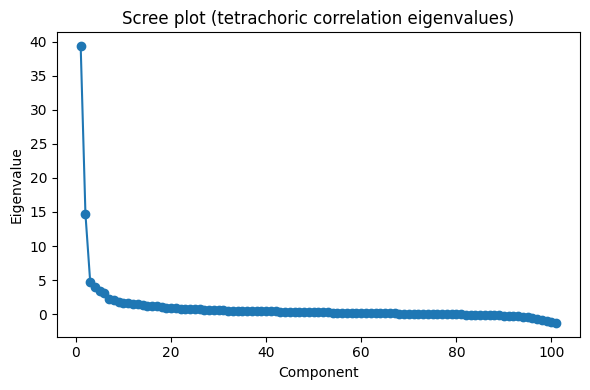

Scree plot saved to /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/processed/results/02_moore_gordon_factor_replication/scree_plot.png


In [59]:
# ---
# NEW: Eigenvalues, scree, and parallel analysis for factor count justification
# ---

# Eigenvalues of tetrachoric correlation matrix (raw + PSD)

evals_raw = np.linalg.eigvalsh(tetra_corr_df.values)
evals_psd = np.linalg.eigvalsh(tetra_corr_psd_df.values)
evals_raw_sorted = np.sort(evals_raw)[::-1]
evals_psd_sorted = np.sort(evals_psd)[::-1]

print("Top 15 eigenvalues (raw):", evals_raw_sorted[:15])
print("Top 15 eigenvalues (psd):", evals_psd_sorted[:15])

plt.figure(figsize=(7, 4))
plt.plot(
    np.arange(1, len(evals_raw_sorted) + 1),
    evals_raw_sorted,
    marker="o",
    label="raw",
)
plt.plot(
    np.arange(1, len(evals_psd_sorted) + 1),
    evals_psd_sorted,
    marker="o",
    label="psd (smoothed)",
)
plt.title("Scree plot (tetrachoric eigenvalues)")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.legend()
plt.tight_layout()

scree_path = os.path.join(RESULTS_DIR, "scree_plot.png")
plt.savefig(scree_path, dpi=300)
plt.show()
print("Scree plot saved to", scree_path)

# Parallel analysis (normal-theory null) on PSD-smoothed matrix

n_obs = binary_matrix.shape[0]
n_vars = binary_matrix.shape[1]
n_perm = 500
rng = np.random.default_rng(42)
sim_eigs = np.empty((n_perm, n_vars))
for b in range(n_perm):
    sim = rng.standard_normal(size=(n_obs, n_vars))
    sim_corr = np.corrcoef(sim, rowvar=False)
    sim_eigs[b] = np.sort(np.linalg.eigvalsh(sim_corr))[::-1]

pa_mean = sim_eigs.mean(axis=0)
pa_p95 = np.percentile(sim_eigs, 95, axis=0)

pa_df = pd.DataFrame(
    {
        "component": np.arange(1, n_vars + 1),
        "actual_eigen_psd": evals_psd_sorted,
        "pa_mean": pa_mean,
        "pa_p95": pa_p95,
    }
)
pa_csv_path = os.path.join(RESULTS_DIR, "parallel_analysis.csv")
pa_df.to_csv(pa_csv_path, index=False)

plt.figure(figsize=(7, 4))
plt.plot(pa_df["component"], pa_df["actual_eigen_psd"], label="actual (psd)")
plt.plot(pa_df["component"], pa_df["pa_p95"], label="PA 95th pct", linestyle="--")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.title("Parallel analysis (500 perms, normal null)")
plt.legend()
plt.tight_layout()

pa_plot_path = os.path.join(RESULTS_DIR, "parallel_analysis_plot.png")
plt.savefig(pa_plot_path, dpi=300)
plt.show()
print("Parallel analysis saved to", pa_csv_path, "and", pa_plot_path)


In [60]:
# ---
# CELL 6: Initial EFA with 2 factors (oblique)
# ---

efa_init = FactorAnalyzer(
    n_factors=2,
    method="minres",
    rotation="promax",
    is_corr_matrix=True,
)
efa_init.fit(tetra_corr_psd)

loadings_init = pd.DataFrame(
    efa_init.loadings_,
    index=binary_matrix.columns,
    columns=["F1", "F2"],
)

loadings_with_rates = loadings_init.join(pct_selected)
init_loadings_path = os.path.join(RESULTS_DIR, "initial_factor_loadings.csv")
loadings_with_rates.to_csv(init_loadings_path)

print("Initial factor loadings (PSD-smoothed tetrachoric):")
display(loadings_with_rates.head())


Initial factor loadings:


,F1,F2,pct_selected
Khaled_Hosseini_mod1,0.644136,-0.056722,15.095368
Donna_Tartt_mod2,0.677967,0.078316,29.809264
Archibald_Cronin_cla1,0.657855,-0.023473,14.550409
Gillian_Flynn_det1,0.539752,0.025890,15.531335
Gabriel_Garsia_Marquez_cla2,0.837466,0.106508,75.694823


In [61]:
# ---
# CELL 7: Identify candidate guessing factor by mean endorsement of high-load items
# ---

LOAD_THRESH = 0.40

avg_endorse_f1 = loadings_with_rates.loc[
    loadings_with_rates["F1"].abs() > LOAD_THRESH, "pct_selected"
].mean()
avg_endorse_f2 = loadings_with_rates.loc[
    loadings_with_rates["F2"].abs() > LOAD_THRESH, "pct_selected"
].mean()

if pd.isna(avg_endorse_f1):
    avg_endorse_f1 = 0.0
if pd.isna(avg_endorse_f2):
    avg_endorse_f2 = 0.0

guessing_factor = "F1" if avg_endorse_f1 < avg_endorse_f2 else "F2"

print(f"Mean pct_selected for high |F1|: {avg_endorse_f1:.2f}")
print(f"Mean pct_selected for high |F2|: {avg_endorse_f2:.2f}")
print("Identified guessing factor:", guessing_factor)


Mean pct_selected for high |F1|: 53.65
Mean pct_selected for high |F2|: 37.04
Identified guessing factor: F2


In [62]:
# ---
# CELL 8: Flag items meeting guessing-factor removal criteria
# ---

LOW_ENDORSE = 10.0

# Debug: check guessing_factor value and loadings shape
print(f"Guessing factor: {guessing_factor}")
print(f"LOAD_THRESH: {LOAD_THRESH}")
print(f"LOW_ENDORSE: {LOW_ENDORSE}")
print(f"loadings_with_rates shape: {loadings_with_rates.shape}")

# Check how many items pass each condition separately
high_load_mask = loadings_with_rates[guessing_factor].abs() > LOAD_THRESH
low_endorse_mask = loadings_with_rates["pct_selected"] < LOW_ENDORSE

print(f"Items with |{guessing_factor}| > {LOAD_THRESH}: {high_load_mask.sum()}")
print(f"Items with pct_selected < {LOW_ENDORSE}: {low_endorse_mask.sum()}")

flagged = loadings_with_rates[high_load_mask & low_endorse_mask]

print("Items to remove (guessing factor candidates):")
display(flagged)
print(f"Flagged {len(flagged)} items.")

flagged_path = os.path.join(RESULTS_DIR, "flagged_guessing_items.csv")
flagged.to_csv(flagged_path)
print(f"Flagged items saved to {flagged_path} (may be empty)")


Guessing factor: F2
LOAD_THRESH: 0.4
LOW_ENDORSE: 10.0
loadings_with_rates shape: (101, 3)
Items with |F2| > 0.4: 29
Items with pct_selected < 10.0: 5
Items to remove (guessing factor candidates):


,F1,F2,pct_selected


Flagged 0 items.
Flagged items saved to /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/processed/results/02_moore_gordon_factor_replication/flagged_guessing_items.csv (may be empty)


In [63]:
# ---
# CELL 9: Remove flagged items & build cleaned binary matrix
# ---

remove_list = flagged.index.tolist()
clean_cols = [c for c in binary_matrix.columns if c not in remove_list]
clean_matrix = binary_matrix[clean_cols]

print("Cleaned matrix shape:", clean_matrix.shape)
print("Removed items:", remove_list)


Cleaned matrix shape: (1835, 101)
Removed items: []


In [64]:
# ---
# CELL 10: Recompute tetrachoric & re-run EFA (2 factors) after removal
# ---

# Recompute tetrachoric using factor_analyzer on cleaned matrix


tetra_corr_clean, fallback_pairs_clean = calculate_tetrachoric_matrix(
    clean_matrix.values, item_names=clean_cols
)

fallback_count_clean = len(fallback_pairs_clean)
total_pairs_clean = clean_matrix.shape[1] * (clean_matrix.shape[1] - 1) // 2
print("Fallback pairs (cleaned):", fallback_count_clean, "of", total_pairs_clean)

fallback_log_clean_path = os.path.join(
    RESULTS_DIR, "tetrachoric_fallback_pairs_after_removal.csv"
)
pd.DataFrame(
    fallback_pairs_clean, columns=["i", "j", "item_i", "item_j"]
).to_csv(fallback_log_clean_path, index=False)



tetra_corr_clean_df = pd.DataFrame(
    tetra_corr_clean,
    index=clean_cols,
    columns=clean_cols,
)
tetra_corr_clean_raw_path = os.path.join(
    RESULTS_DIR, "tetrachoric_correlation_matrix_after_removal_raw.csv"
)
tetra_corr_clean_df.to_csv(tetra_corr_clean_raw_path, index=True)

# Smooth cleaned matrix




tetra_corr_clean_psd = near_psd(tetra_corr_clean_df.values, eps=1e-6)
tetra_corr_clean_psd_df = pd.DataFrame(
    tetra_corr_clean_psd,
    index=clean_cols,
    columns=clean_cols,
)
tetra_corr_clean_psd_path = os.path.join(
    RESULTS_DIR, "tetrachoric_correlation_matrix_after_removal_psd.csv"
)
tetra_corr_clean_psd_df.to_csv(tetra_corr_clean_psd_path, index=True)

print(
    "Cleaned tetrachoric saved (raw+PSD):",
    tetra_corr_clean_raw_path,
    tetra_corr_clean_psd_path,
    "shape:",
    tetra_corr_clean_df.shape,
)
print(
    "Min eigen (raw):",
    np.linalg.eigvalsh(tetra_corr_clean_df.values).min(),
    "; min eigen (psd):",
    np.linalg.eigvalsh(tetra_corr_clean_psd_df.values).min(),
)
print("Fallback log (clean) saved to", fallback_log_clean_path)

efa_two = FactorAnalyzer(
    n_factors=2,
    method="minres",
    rotation="promax",
    is_corr_matrix=True,
)
efa_two.fit(tetra_corr_clean_psd)

loadings_two = pd.DataFrame(
    efa_two.loadings_,
    index=clean_cols,
    columns=["F1", "F2"],
)
loadings_two_with_rates = loadings_two.join(pct_selected.loc[clean_cols])

after_loadings_path = os.path.join(RESULTS_DIR, "efa_after_removal_loadings.csv")
loadings_two_with_rates.to_csv(after_loadings_path)

print("EFA loadings AFTER removal (PSD-smoothed):")
display(loadings_two_with_rates.head())


EFA loadings AFTER removal:


,F1,F2,pct_selected
Khaled_Hosseini_mod1,0.644136,-0.056722,15.095368
Donna_Tartt_mod2,0.677967,0.078316,29.809264
Archibald_Cronin_cla1,0.657855,-0.023473,14.550409
Gillian_Flynn_det1,0.539752,0.025890,15.531335
Gabriel_Garsia_Marquez_cla2,0.837466,0.106508,75.694823


In [65]:
# ---
# CELL 11: 1 vs 2 factor diagnostics (variance explained + residual norms)
# ---

# 1-factor solution (using PSD-smoothed correlation matrices)


efa_one = FactorAnalyzer(
    n_factors=1,
    method="minres",
    rotation=None,
    is_corr_matrix=True,
)
efa_one.fit(tetra_corr_clean_psd)

# Variance explained
var1 = efa_one.get_factor_variance()
var2 = efa_two.get_factor_variance()
print(f"1-factor cumulative variance explained: {var1[2][0]*100:.2f}%")
print(f"2-factor cumulative variance explained: {var2[2][1]*100:.2f}%")

# Model-implied correlation matrices and residual diagnostics

def implied_corr(fa: FactorAnalyzer) -> np.ndarray:
    loadings = fa.loadings_
    uniq = fa.get_uniquenesses()
    return loadings @ loadings.T + np.diag(uniq)

implied1 = implied_corr(efa_one)
implied2 = implied_corr(efa_two)

resid1 = tetra_corr_clean_psd - implied1
resid2 = tetra_corr_clean_psd - implied2

fro1 = np.linalg.norm(resid1, ord="fro")
fro2 = np.linalg.norm(resid2, ord="fro")
max_resid1 = np.abs(resid1).max()
max_resid2 = np.abs(resid2).max()

print("Residual Frobenius norm (1-factor):", fro1)
print("Residual Frobenius norm (2-factor):", fro2)
print("Max residual abs (1-factor):", max_resid1)
print("Max residual abs (2-factor):", max_resid2)

fit_diag_path = os.path.join(RESULTS_DIR, "fit_diagnostics.txt")
with open(fit_diag_path, "w") as f:
    f.write(f"Items after removal: {clean_matrix.shape[1]}\n")
    f.write(f"1-factor cumulative variance: {var1[2][0]*100:.4f}\n")
    f.write(f"2-factor cumulative variance: {var2[2][1]*100:.4f}\n")
    f.write(f"resid_fro_1: {fro1}\n")
    f.write(f"resid_fro_2: {fro2}\n")
    f.write(f"resid_max_1: {max_resid1}\n")
    f.write(f"resid_max_2: {max_resid2}\n")
print("Fit diagnostics saved to", fit_diag_path)


1-factor cumulative variance explained: 38.40%
2-factor cumulative variance explained: 52.80%
Residual Frobenius norm (1-factor): 16.797441996472926
Residual Frobenius norm (2-factor): 16.381755816477256
Max residual abs (1-factor): 0.9006443252861955
Max residual abs (2-factor): 0.7711416181385307
Fit diagnostics saved to /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/processed/results/02_moore_gordon_factor_replication/fit_diagnostics.txt


In [66]:
# ---
# CELL 12: Factor correlation (phi matrix)
# ---

phi = getattr(efa_two, "phi_", None)
if phi is None:
    phi = np.eye(efa_two.n_factors)
phi_df = pd.DataFrame(phi, index=["F1", "F2"], columns=["F1", "F2"])
phi_path = os.path.join(RESULTS_DIR, "factor_correlation_phi.csv")
phi_df.to_csv(phi_path)
print("Factor inter-correlation (phi):\n", phi_df)


Factor inter-correlation (phi):
           F1        F2
F1  1.000000  0.380507
F2  0.380507  1.000000


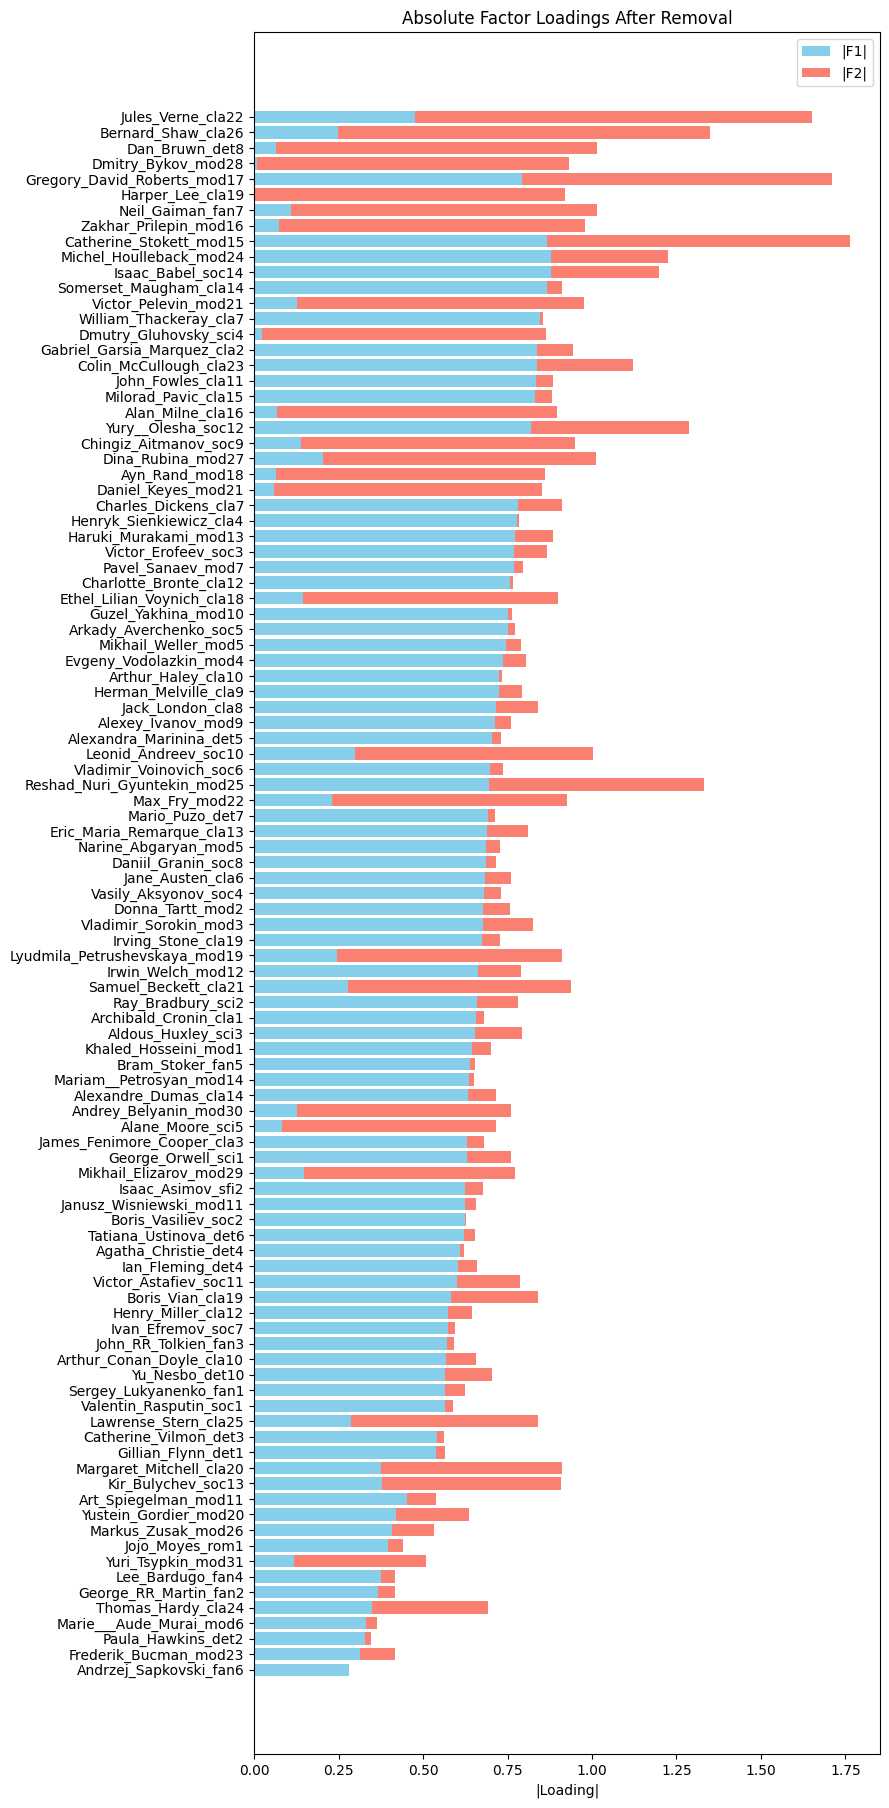

Absolute loadings plot saved to /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/processed/results/02_moore_gordon_factor_replication/abs_loadings_plot.png


In [67]:
# ---
# CELL 13: Plot absolute loadings for Factor 1 & Factor 2
# ---

abs_loadings = loadings_two.abs()
abs_loadings["max"] = abs_loadings.max(axis=1)
abs_sorted = abs_loadings.sort_values("max", ascending=True)

plt.figure(figsize=(9, max(6, len(abs_sorted) * 0.18)))
plt.barh(abs_sorted.index, abs_sorted["F1"], color="skyblue", label="|F1|")
plt.barh(abs_sorted.index, abs_sorted["F2"], left=abs_sorted["F1"], color="salmon", label="|F2|")
plt.title("Absolute Factor Loadings After Removal")
plt.xlabel("|Loading|")
plt.legend()
plt.tight_layout()

abs_plot_path = os.path.join(RESULTS_DIR, "abs_loadings_plot.png")
plt.savefig(abs_plot_path, dpi=300)
plt.show()
print("Absolute loadings plot saved to", abs_plot_path)


In [68]:
# ---
# CELL 14: Build & save tables of top loadings per factor
# ---

TOP_N = 15

# Sort by absolute loading to capture strongest contributors


top_f1 = loadings_two.reindex(loadings_two["F1"].abs().sort_values(ascending=False).index).head(TOP_N)
top_f2 = loadings_two.reindex(loadings_two["F2"].abs().sort_values(ascending=False).index).head(TOP_N)

top_f1_path = os.path.join(RESULTS_DIR, "top_F1_loadings.csv")
top_f2_path = os.path.join(RESULTS_DIR, "top_F2_loadings.csv")
top_f1.to_csv(top_f1_path)
top_f2.to_csv(top_f2_path)

print("Top F1 loadings:")
display(top_f1)
print("Top F2 loadings:")
display(top_f2)


Top F1 loadings:


,F1,F2
Michel_Houlleback_mod24,0.880107,-0.346245
Isaac_Babel_soc14,0.877245,-0.321260
Somerset_Maugham_cla14,0.868237,0.041788
Catherine_Stokett_mod15,0.866144,-0.898023
William_Thackeray_cla7,0.845905,0.009121
Gabriel_Garsia_Marquez_cla2,0.837466,0.106508
Colin_McCullough_cla23,0.836408,-0.283746
John_Fowles_cla11,0.835761,0.049834
Milorad_Pavic_cla15,0.830949,0.051588
Yury__Olesha_soc12,0.818811,-0.469367


Top F2 loadings:


,F1,F2
Jules_Verne_cla22,-0.476814,1.175271
Bernard_Shaw_cla26,-0.249108,1.099513
Dan_Bruwn_det8,-0.064932,0.950144
Dmitry_Bykov_mod28,0.008019,0.923901
Gregory_David_Roberts_mod17,0.791796,-0.917499
Harper_Lee_cla19,0.002941,0.916920
Neil_Gaiman_fan7,-0.108065,0.907467
Zakhar_Prilepin_mod16,0.073831,0.904599
Catherine_Stokett_mod15,0.866144,-0.898023
Victor_Pelevin_mod21,0.127888,0.847906


In [69]:
# ---
# CELL 15: Save final loadings with endorsement info
# ---

final_table = loadings_two.join(pct_selected.loc[clean_cols])
final_table_path = os.path.join(RESULTS_DIR, "final_EFA_results_table.csv")
final_table.to_csv(final_table_path)

print("Final EFA table saved to", final_table_path)
display(final_table.head(15))


Final EFA table saved to /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/processed/results/02_moore_gordon_factor_replication/final_EFA_results_table.csv


,F1,F2,pct_selected
Khaled_Hosseini_mod1,0.644136,-0.056722,15.095368
Donna_Tartt_mod2,0.677967,0.078316,29.809264
Archibald_Cronin_cla1,0.657855,-0.023473,14.550409
Gillian_Flynn_det1,0.539752,0.025890,15.531335
Gabriel_Garsia_Marquez_cla2,0.837466,0.106508,75.694823
James_Fenimore_Cooper_cla3,0.631231,0.048458,64.959128
Henryk_Sienkiewicz_cla4,0.778857,0.004574,42.125341
Paula_Hawkins_det2,0.327327,0.017609,13.841962
George_Orwell_sci1,0.628942,0.129955,90.081744
Jane_Austen_cla6,0.681917,0.077277,85.068120


In [70]:
# ---
# NEW: Verification checks for alignment and exports
# ---

# Shapes and column alignment
assert binary_matrix.shape[1] == pct_selected.shape[0], "Item count mismatch between matrix and pct_selected"
assert set(binary_matrix.columns) == set(pct_selected.index), "Column labels mismatch"

# Correlation sanity
assert np.isfinite(tetra_corr_df.values).all(), "NaNs found in tetrachoric correlation matrix (raw)"
assert np.isfinite(tetra_corr_psd_df.values).all(), "NaNs found in tetrachoric correlation matrix (psd)"
assert np.isfinite(tetra_corr_clean_df.values).all(), "NaNs found in cleaned tetrachoric matrix (raw)"
assert np.isfinite(tetra_corr_clean_psd_df.values).all(), "NaNs found in cleaned tetrachoric matrix (psd)"

# Loadings table alignment
assert loadings_two_with_rates.shape[0] == len(clean_cols), "Loadings rows do not match cleaned columns"
assert set(loadings_two_with_rates.index) == set(clean_cols), "Loadings index mismatch"

# Reload final table to confirm export integrity
final_reload = pd.read_csv(final_table_path, index_col=0)
print("Reloaded final table shape:", final_reload.shape)


Reloaded final table shape: (101, 3)


In [71]:
# ---
# CELL 16: Write a summary report
# ---

summary_path = os.path.join(RESULTS_DIR, "summary.txt")
with open(summary_path, "w") as f:
    f.write("Moore & Gordon–style EFA summary\n")
    f.write(f"N={binary_matrix.shape[0]}\n")
    f.write(f"P initial (post-filter): {len(new_item_names)}\n")
    f.write(f"Dropped zero-variance items: {len(dropped)}\n")
    f.write(f"Removed items (guessing factor): {len(remove_list)}\n")
    f.write(f"P final: {len(clean_cols)}\n")
    f.write(
        "Guessing factor (by lower mean endorsement among |loading|>.40): "
        f"{guessing_factor}\n"
    )
    f.write(f"Tetrachoric fallbacks (initial/clean): {fallback_count}/{fallback_count_clean}\n")
    f.write(f"1-factor cumulative variance: {var1[2][0]*100:.4f}\n")
    f.write(f"2-factor cumulative variance: {var2[2][1]*100:.4f}\n")
    f.write(f"resid_fro_1: {fro1}\n")
    f.write(f"resid_fro_2: {fro2}\n")
    f.write(f"resid_max_1: {max_resid1}\n")
    f.write(f"resid_max_2: {max_resid2}\n")
    f.write(
        "Parallel analysis 95th pct (first 5 comps): "
        f"{pa_p95[:5].round(4).tolist()}\n"
    )

print("Summary text file written to", summary_path)

Summary text file written to /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/processed/results/02_moore_gordon_factor_replication/summary.txt
